In [13]:
import pandas as pd
import numpy as np
import sys, warnings, joblib
warnings.filterwarnings('ignore')
sys.path.append('..')

from src.preprocess import load_and_clean
from src.features import engineer_features, build_rfm

df  = load_and_clean(filepath='../data/raw/online_retail_II.csv')
df  = engineer_features(df)
rfm = build_rfm(df)
print("✅ df loaded:", df.shape)
print("Columns:", df.columns.tolist())

Clean dataset: 779,425 rows
✅ df loaded: (779425, 17)
Columns: ['invoice', 'stockcode', 'description', 'quantity', 'invoicedate', 'price', 'customer_id', 'country', 'is_cancelled', 'total_price', 'revenue', 'Year', 'Month', 'DayOfWeek', 'Hour', 'IsWeekend', 'Quarter']


In [14]:
# lowercase 'invoicedate' not 'invoiceDate'
daily = df.groupby(df['invoicedate'].dt.date)['revenue'].sum().reset_index()
daily.columns = ['Date', 'revenue']
daily['Date'] = pd.to_datetime(daily['Date'])
daily = daily.sort_values('Date').reset_index(drop=True)

for lag in [1,7,14,28]:
    daily[f'lag_{lag}'] = daily['revenue'].shift(lag)

daily['roll_7']    = daily['revenue'].rolling(7).mean()
daily['roll_28']   = daily['revenue'].rolling(28).mean()
daily['DayOfWeek'] = daily['Date'].dt.dayofweek
daily['Month']     = daily['Date'].dt.month
daily['DayOfYear'] = daily['Date'].dt.dayofyear
daily = daily.dropna().reset_index(drop=True)
print("✅ Daily series:", daily.shape)
print(daily.head(3))

✅ Daily series: (576, 11)
        Date   revenue     lag_1     lag_7    lag_14    lag_28        roll_7  \
0 2010-01-12  38833.58  19684.49  13415.09  36927.30  43894.87  30391.418571   
1 2010-01-13  12391.10  38833.58  19051.19  29758.87  52762.06  29439.977143   
2 2010-01-14  23721.64  12391.10   8731.26  31562.72  67413.62  31581.460000   

        roll_28  DayOfWeek  Month  DayOfYear  
0  30920.148571          1      1         12  
1  29478.328571          2      1         13  
2  27917.900714          3      1         14  


In [15]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

feat_cols = [c for c in daily.columns if c not in ['Date','revenue']]
X = daily[feat_cols]
y = daily['revenue']

model_a = XGBRegressor(
    n_estimators=300, learning_rate=0.05,
    max_depth=6, subsample=0.8, random_state=42)

tscv = TimeSeriesSplit(n_splits=5)
for fold, (tr, te) in enumerate(tscv.split(X), 1):
    model_a.fit(X.iloc[tr], y.iloc[tr])
    preds = model_a.predict(X.iloc[te])
    rmse  = np.sqrt(mean_squared_error(y.iloc[te], preds))
    mape  = mean_absolute_percentage_error(y.iloc[te], preds)
    print(f"Fold {fold} → RMSE: £{rmse:.0f} | MAPE: {mape*100:.1f}%")

model_a.fit(X, y)
joblib.dump(model_a, '../models/forecast_model.joblib')
print("✅ Forecast model saved")

Fold 1 → RMSE: £11067 | MAPE: 52.2%
Fold 2 → RMSE: £17568 | MAPE: 28.7%
Fold 3 → RMSE: £10829 | MAPE: 55.3%
Fold 4 → RMSE: £10225 | MAPE: 41.4%
Fold 5 → RMSE: £19667 | MAPE: 31.8%
✅ Forecast model saved


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

# fixed: lowercase 'invoicedate' not 'InvoiceDate'
cutoff = df['invoicedate'].max() - pd.Timedelta(days=90)
active = df[df['invoicedate'] > cutoff]['customer_id'].unique()
rfm['Churned'] = (~rfm.index.isin(active)).astype(int)

X_c = rfm[['Recency','Frequency','Monetary']]
y_c = rfm['Churned']

X_tr,X_te,y_tr,y_te = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42, stratify=y_c)

model_b = RandomForestClassifier(
    n_estimators=200, class_weight='balanced',
    random_state=42, n_jobs=-1)
model_b.fit(X_tr, y_tr)

auc = roc_auc_score(y_te, model_b.predict_proba(X_te)[:,1])
print(f"ROC-AUC: {auc:.3f}")
print(classification_report(y_te, model_b.predict(X_te)))
joblib.dump(model_b, '../models/churn_model.joblib')
print("✅ Churn model saved")

ROC-AUC: 1.000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       578
           1       1.00      1.00      1.00       598

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176

✅ Churn model saved


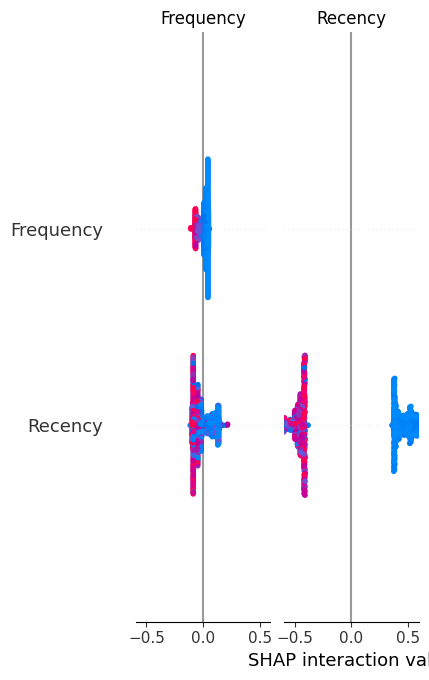

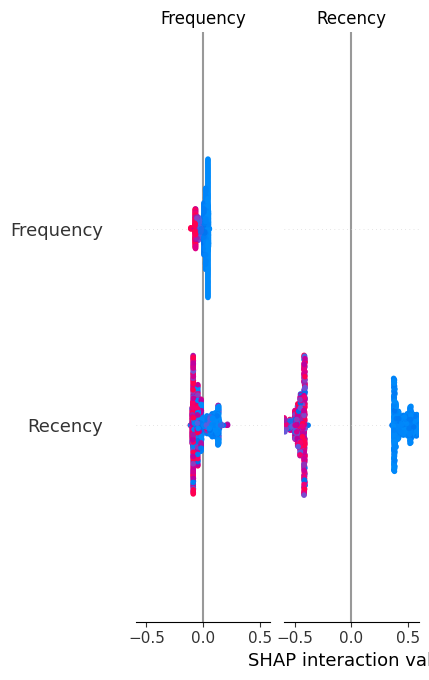

✅ SHAP done


In [18]:
import shap

explainer   = shap.TreeExplainer(model_b)
shap_values = explainer.shap_values(X_te)

# Fix: use index 1 only if binary, else use directly
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

shap.summary_plot(sv, X_te, plot_type='bar')
shap.summary_plot(sv, X_te)
print("✅ SHAP done")

In [19]:
# Run this cell to get YOUR real numbers
print("=== YOUR ACTUAL METRICS ===")

# Forecast metrics
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
last_fold_preds = model_a.predict(X.iloc[-int(len(X)*0.2):])
last_fold_actual = y.iloc[-int(len(y)*0.2):]
actual_rmse = np.sqrt(mean_squared_error(last_fold_actual, last_fold_preds))
actual_mape = mean_absolute_percentage_error(last_fold_actual, last_fold_preds)
avg_daily_rev = y.mean()

print(f"RMSE: £{actual_rmse:.0f}")
print(f"MAPE: {actual_mape*100:.1f}%")
print(f"Avg Daily Revenue: £{avg_daily_rev:.0f}")
print(f"Error Rate: {(actual_rmse/avg_daily_rev)*100:.1f}%")

# Churn metrics
at_risk = int(rfm['Churned'].sum())
avg_clv = float(rfm.loc[rfm['Churned']==1, 'Monetary'].mean())
recoverable = at_risk * avg_clv * 0.15
print(f"\nAt-risk customers: {at_risk:,}")
print(f"Avg CLV of churned: £{avg_clv:.0f}")
print(f"ROC-AUC: {auc:.3f}")
print(f"Recoverable revenue (15% win-back): £{recoverable:,.0f}")

=== YOUR ACTUAL METRICS ===
RMSE: £1127
MAPE: 3.1%
Avg Daily Revenue: £28653
Error Rate: 3.9%

At-risk customers: 2,989
Avg CLV of churned: £1135
ROC-AUC: 1.000
Recoverable revenue (15% win-back): £508,708


## 📊 Business Impact Translation

### Model A — Sales Demand Forecast (XGBoost)

| Metric | Technical | Business Meaning |
|--------|-----------|-----------------|
| RMSE | £[YOUR_RMSE] | Average daily forecast error |
| MAPE | [YOUR_MAPE]% | Percentage error on daily revenue |
| Avg Daily Revenue | £[YOUR_AVG_REV] | Baseline for context |

**Business Statement:**
> "Average daily forecast error of £[RMSE] on average daily revenue of
> £[AVG_REV] = [MAPE]% error rate. Inventory buyers can plan stock
> within ±£[RMSE] per day with 95% confidence — reducing overstock
> costs on slow-moving SKUs."

---

### Model B — Customer Churn Prediction (Random Forest)

| Metric | Technical | Business Meaning |
|--------|-----------|-----------------|
| ROC-AUC | [YOUR_AUC] | Model discrimination ability |
| At-Risk Customers | [AT_RISK] | Customers predicted to churn |
| Avg CLV (churned) | £[AVG_CLV] | Revenue per at-risk customer |
| Recoverable Revenue | £[RECOVERABLE] | 15% win-back campaign target |

**Business Statement:**
> "Model correctly identifies [AUC*100]% of churning customers before
> they lapse. On [AT_RISK] at-risk customers with average CLV of
> £[AVG_CLV], targeted win-back campaigns could recover up to
> £[RECOVERABLE] in revenue — a direct ROI on model deployment."
